In [1]:
import autograd.numpy as np
import capytaine as cpy
import matplotlib.pyplot as plt
from matplotlib import cm

import wecopttool as wot
from capytaine.io.meshio import load_from_meshio
import os

In [2]:
wot.set_loglevel('ERROR', capytaine=False)

results_dir = 'data'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

In [3]:
wb = wot.geom.WaveBot()  # use standard dimensions
mesh_size_factor = 0.5 # 1.0 for default, smaller to refine mesh
mesh = wb.mesh(mesh_size_factor)

# create mesh object for WaveBot and add internal lid
mesh_obj = load_from_meshio(mesh, 'WaveBot')
lid_mesh = mesh_obj.generate_lid(-2e-2)

fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="WaveBot")
fb.add_translation_dof(name="Heave")
ndof = fb.nb_dofs

In [4]:
wavefreq = 0.3# Hz
f1 = wavefreq
nfreq = 5

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency
amplitude = 0.0625 # m
phase = 30 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

In [5]:
fname_string = 'bem_wavebot_f1_'+ str.replace(f'{f1}','.','p') +'Hz_nfreq'+ f'{nfreq}' +'.nc'
fname_wec = os.path.join(results_dir, fname_string)
if os.path.exists(fname_wec):
    bem_data = wot.read_netcdf(fname_wec)
else:
    bem_data = wot.run_bem(fb, freq)
    wot.write_netcdf(fname_wec, bem_data)

The resolution of the mesh might be insufficient for omega ranging from 9.425 to 9.425.
This warning appears when the largest panel of this mesh has radius > wavelength/8.


[09:17:29] WARNING  Mesh resolution for 2 problems:                                                                
                    The resolution of the mesh might be insufficient for omega ranging from 9.425 to 9.425.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

In [6]:
hd = wot.add_linear_friction(bem_data, friction = None) 
hd = wot.check_radiation_damping(hd)

In [7]:
## PTO impedance definition
omega = bem_data.omega.values


In [8]:
nsubsteps = 4

def wec_pto_and_res_enforced_vel(fd_vel_target = None, K_DT = 0, obj_fun ='elec'):

    gear_ratio = 12.0
    torque_constant = 6.7
    winding_resistance = 0.5
    winding_inductance = 0.0
    drivetrain_inertia = 2.0
    drivetrain_friction = 1.0
    drivetrain_stiffness = K_DT

    drivetrain_impedance = (1j*omega*drivetrain_inertia + 
                            drivetrain_friction + 
                            1/(1j*omega)*drivetrain_stiffness) 

    winding_impedance = winding_resistance + 1j*omega*winding_inductance


    pto_impedance_11 = -1* gear_ratio**2 * drivetrain_impedance
    off_diag = np.sqrt(3.0/2.0) * torque_constant * gear_ratio
    pto_impedance_12 = -1*(off_diag+0j) * np.ones(omega.shape) 
    pto_impedance_21 = -1*(off_diag+0j) * np.ones(omega.shape)
    pto_impedance_22 = winding_impedance
    pto_impedance = np.array([[pto_impedance_11, pto_impedance_12],
                                [pto_impedance_21, pto_impedance_22]])

    loss = None
    # controller = wot.pto.controller_pi
    # nstate_opt = 2 
    controller = None
    nstate_opt = 2 * nfreq 



    name = ["PTO_Heave",]
    kinematics = np.eye(ndof)
    pto = wot.pto.PTO(ndof, kinematics, controller, pto_impedance, loss, name)


    def const_fd_vel_mag(wec, x_wec, x_opt, waves): 
        pos_wec = wec.vec_to_dofmat(x_wec)
        vel_wec = np.dot(wec.derivative_mat, pos_wec)
        #vel_wec has real frequency components, first non-zero frequency is wave req, at place 1 and 2, then I take the magnitude
        delta_vel = fd_vel_target - (np.sqrt(vel_wec[1]**2 + vel_wec[2]**2))  
        tolerance = 0.0001
        return tolerance - np.abs(delta_vel)

    

    if fd_vel_target is None:
        constraints = []
        print_str = "Unconstrained"
    else:
        constraints = [{'type': 'ineq', 'fun': const_fd_vel_mag}]
        print_str = f"V_target: {fd_vel_target:.2f}"

    if obj_fun == 'elec':
        obj_fun = pto.average_power
    elif obj_fun == 'use':
        def useful_power(wec, x_wec, x_opt, waves, nsubsteps = 1):
            q2_td, e2_td =pto.power_variables(wec, x_wec,
                                            x_opt, waves, nsubsteps)
            vel_td = pto.velocity(wec, x_wec, x_opt, waves, nsubsteps)
            P_use_td = -1*off_diag*q2_td*vel_td
            W_use = np.sum(P_use_td) * wec.dt/nsubsteps
            P_use_avg = W_use/ wec.tf
            # print(f'Pavg use {P_use_avg}') 
            return P_use_avg
        obj_fun = useful_power
    elif obj_fun == 'mech':
        obj_fun = pto.mechanical_average_power + pto.average_power
    elif obj_fun == 'combined':
        def combined_power(wec, x_wec, x_opt, waves, nsubsteps = 1):
            Pmech= pto.mechanical_average_power(wec, x_wec, x_opt, waves)
            Pelec = pto.average_power(wec, x_wec, x_opt, waves)
            return 10*Pmech+ Pelec
        obj_fun = combined_power
    else:
        raise ValueError ("Either 'elec', 'use, 'combined', or 'mech' as obj_fun argument")

    f_add = {'PTO': pto.force_on_wec}

    wec = wot.WEC.from_bem(
        bem_data,
        constraints=constraints,
        friction=None,
        f_add=f_add,
    )
    # obj_fun = pto.average_power

    options = {'maxiter': 300,
               'disp': False}
    scale_x_wec = 1e1
    scale_x_opt = 1e-3
    scale_obj = 1e-2

    results = wec.solve(
        waves, 
        obj_fun, 
        nstate_opt,
        optim_options=options, 
        scale_x_wec=scale_x_wec,
        scale_x_opt=scale_x_opt,
        scale_obj=scale_obj,
        )
    opt_average_power = results[0].fun
    print(print_str + f', opt power: {opt_average_power:.2f} W')
    return wec, pto, results


In [9]:
wec, pto, results = wec_pto_and_res_enforced_vel(0.3)
pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
w_fd = wec_fdom[0]
p_fd = pto_fdom[0]
Fexc = w_fd['force'].sel(type = ['Froude_Krylov', 'diffraction']).sum(dim = 'type')
np.abs(w_fd['vel'][1].values)

V_target: 0.30, opt power: 21.35 W


array([0.29990002])

## SEtup power curves after Falnes

In [10]:
Zi = wot.hydrodynamic_impedance(hd)
gear_ratio = 12.0
drivetrain_friction = 1.0
R11 =  gear_ratio**2 * drivetrain_friction

clrs = wot.utilities.power_flow_colors()

u_opt_abs = (np.abs(Fexc.squeeze().values[1:])/(2*np.real(Zi.squeeze().values)))[0]
u_opt_use = (np.abs(Fexc.squeeze().values[1:])/(2*(np.real(Zi.squeeze().values) +R11)))[0]
u_opt_abs, u_opt_use

AttributeError: module 'wecopttool.utilities' has no attribute 'power_flow_colors'

## V2 with enforced vel

In [ ]:
def power_flows_per_vel(K_DT = 0, obj_fun = 'elec'):
    P_load = []
    P_ex = []
    P_abs = []
    P_use = []
    # rms_vel = []
    mag_vel = []
    mag_current = []
    vel_targetd_vec = np.linspace(0.05, 1, 16)
    for vel_target in vel_targetd_vec:
        wec, pto, results = wec_pto_and_res_enforced_vel(vel_target, K_DT= K_DT, obj_fun= obj_fun)
        p_flows = wot.utilities.calculate_power_flows(wec, pto, results, waves, Zi)
        wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
        pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)

        w_fd = wec_fdom[0]
        p_fd = pto_fdom[0]

        mag_vel.append(np.max(np.abs(w_fd.vel)))    #if constraints not to hard, should be linear and all zero but wave freq
        # mag_vel.append(np.sqrt(np.mean(wec_tdom[0]['vel'].values**2)))    #if constraints not to hard, should be linear and all zero but wave freq
        P_load.append(p_flows['Electrical'])
        P_ex.append(p_flows['Excitation'])
        P_abs.append(p_flows['Absorbed'])
        # P_abs.append(p_flows['Mechanical'])
        # P_use.append(p_flows['Mechanical'] - p_flows['PTO Loss Mechanical'])
        P_use.append(p_flows['Mechanical'])

        mag_current.append(np.max(np.abs(p_fd.trans_flo)))
        # mag_current.append(np.sqrt(np.mean(pto_tdom[0]['trans_flo'].values**2)))    #if
    return mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows

def plot_power_curves(K_DT, obj_fun_string, mag_vel, P_load, P_ex, P_abs, P_use, p_flows):
    fig, ax = plt.subplots(figsize = (6,4))
    plt.tight_layout
    ax.plot(mag_vel, P_ex, c = clrs['hydro'], label ='$P_{{ex}}$')
    ax.plot(mag_vel, P_abs, c = clrs['mech'], label ='$P_{{abs}}$')
    ax.plot(mag_vel, P_use, c = clrs['mech_elec'], label ='$P_{{use}}$')
    ax.plot(mag_vel, P_load, c = clrs['elec'], label ='$P_{{load}}$')
    # ax.axhline(p_flows['Max Absorbed'], alpha = 0.5, linestyle = '--', linewidth = 0.8, c = clrs['mech'], label = 'Max Abs.')
    # ax.axhline(p_flows['Max Useful'], alpha = 0.5, linestyle = '--', linewidth = 0.8, c = clrs['mech_elec'], label = 'Max Use.')
    # ax.axhline(2*p_flows['Max Useful'], alpha = 0.5, linestyle = '--', linewidth = 0.8, c = clrs['hydro'], label = 'Exc Max Use.')
    # ax.axhline(2*p_flows['Max Useful'], alpha = 0.5, linestyle = '--', linewidth = 0.8, c = clrs['hydro'], label = 'Exc Max Use.')
    ax.hlines(p_flows['Max Absorbed'], 0, u_opt_abs, alpha = 0.5, linestyle = '--', linewidth = 0.8, colors = clrs['mech'], label = 'Max Abs.')
    ax.hlines(p_flows['Max Useful'], 0, u_opt_use, alpha = 0.5, linestyle = '--', linewidth = 0.8, colors = clrs['mech_elec'], label = 'Max use.')
    ax.hlines(2*p_flows['Max Useful'], 0, u_opt_use, alpha = 0.5, linestyle = '--', linewidth = 0.8, colors = clrs['hydro'], label = 'Exc Max Use.')
    ax.hlines(2*p_flows['Max Absorbed'], 0, u_opt_abs, alpha = 0.5, linestyle = '--', linewidth = 0.8, colors = clrs['hydro'], label = 'Exc Max Abs.')

    ax.set_title(f'DT stiff {K_DT:.2f}Nm/rad, obj_fun {obj_fun_string}')
    ax.set_xlabel('$|u|$')
    ax.set_ylabel('Power [W]')
    ax.legend()

    ax.set_ylim(bottom= -100)
    ax.grid()


V_target: 0.05, opt power: -2.47 W
V_target: 0.11, opt power: -24.92 W
V_target: 0.18, opt power: -28.04 W
V_target: 0.24, opt power: -11.84 W
V_target: 0.30, opt power: 23.70 W
V_target: 0.37, opt power: 78.60 W
V_target: 0.43, opt power: 152.85 W
V_target: 0.49, opt power: 246.44 W
V_target: 0.56, opt power: 359.39 W
V_target: 0.62, opt power: 491.69 W
V_target: 0.68, opt power: 643.34 W
V_target: 0.75, opt power: 814.34 W
V_target: 0.81, opt power: 1004.69 W
V_target: 0.87, opt power: 1214.39 W
V_target: 0.94, opt power: 1443.44 W
V_target: 1.00, opt power: 1691.84 W


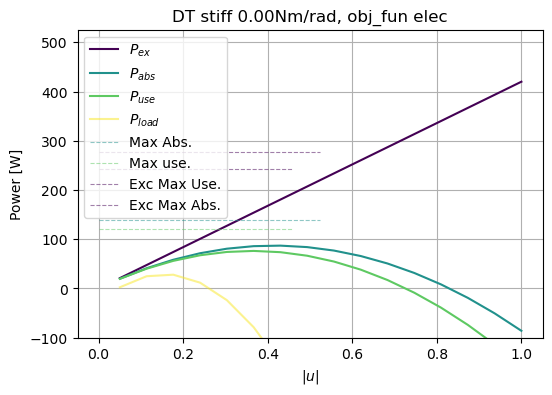

In [ ]:
Kms = 0
obj = 'elec'
mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

V_target: 0.05, opt power: -0.36 W
V_target: 0.11, opt power: -29.26 W
V_target: 0.18, opt power: -48.99 W
V_target: 0.24, opt power: -59.55 W
V_target: 0.30, opt power: -60.95 W
V_target: 0.37, opt power: -53.20 W
V_target: 0.43, opt power: -36.29 W
V_target: 0.49, opt power: -10.21 W
V_target: 0.56, opt power: 25.04 W
V_target: 0.62, opt power: 69.45 W
V_target: 0.68, opt power: 123.03 W
V_target: 0.75, opt power: 185.78 W
V_target: 0.81, opt power: 257.70 W
V_target: 0.87, opt power: 338.79 W
V_target: 0.94, opt power: 429.04 W
V_target: 1.00, opt power: 528.46 W


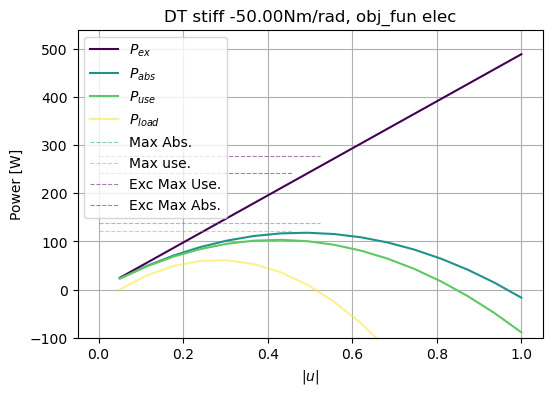

In [ ]:
Kms = -50
obj = 'elec'
mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

V_target: 0.05, opt power: 0.39 W
V_target: 0.11, opt power: -30.09 W
V_target: 0.18, opt power: -54.24 W
V_target: 0.24, opt power: -72.04 W
V_target: 0.30, opt power: -83.50 W
V_target: 0.37, opt power: -88.63 W
V_target: 0.43, opt power: -87.43 W
V_target: 0.49, opt power: -79.89 W
V_target: 0.56, opt power: -66.02 W
V_target: 0.62, opt power: -45.81 W
V_target: 0.68, opt power: -19.26 W
V_target: 0.75, opt power: 13.63 W
V_target: 0.81, opt power: 52.86 W
V_target: 0.87, opt power: 98.43 W
V_target: 0.94, opt power: 150.34 W
V_target: 1.00, opt power: 208.59 W


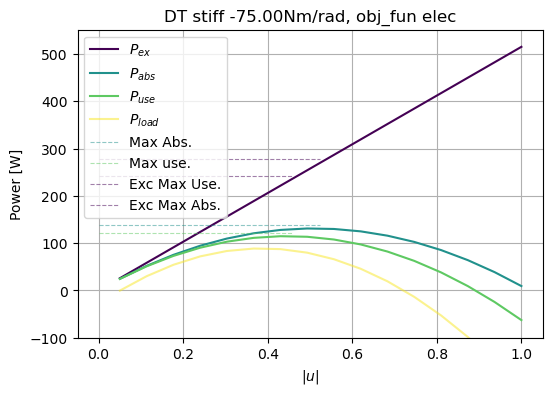

In [ ]:
Kms = -75
obj = 'elec'
mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

V_target: 0.05, opt power: 0.79 W
V_target: 0.11, opt power: -30.44 W
V_target: 0.18, opt power: -56.74 W
V_target: 0.24, opt power: -78.11 W
V_target: 0.30, opt power: -94.56 W
V_target: 0.37, opt power: -106.08 W
V_target: 0.43, opt power: -112.67 W
V_target: 0.49, opt power: -114.34 W
V_target: 0.56, opt power: -111.09 W
V_target: 0.62, opt power: -102.91 W
V_target: 0.68, opt power: -89.81 W
V_target: 0.75, opt power: -71.78 W
V_target: 0.81, opt power: -48.82 W
V_target: 0.87, opt power: -20.93 W
V_target: 0.94, opt power: 11.89 W
V_target: 1.00, opt power: 49.63 W


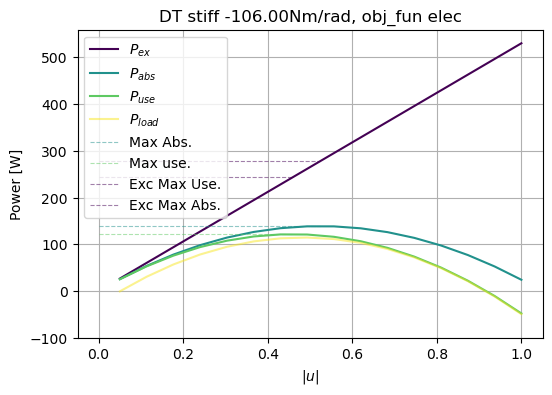

In [ ]:
Kms = -106
obj = 'elec'
mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

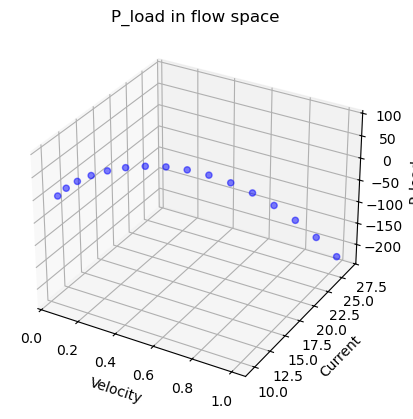

In [ ]:
# Example for P_load
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mag_vel, mag_current, P_load, c='b', marker='o', label='P_load', alpha = 0.5)

ax.set_xlabel('Velocity')
ax.set_ylabel('Current')
ax.set_zlabel('P_load')
plt.title('P_load in flow space')
plt.show()

Unconstrained, opt power: -114.40 W


[09:42:09] WARNING  Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.

           WARNING  Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.

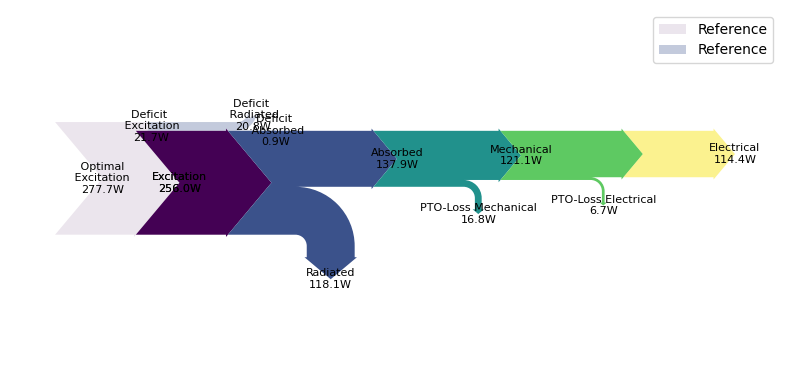

In [ ]:
Kms = -106
# Kms = -70

obj = 'elec'
wec, pto, results = wec_pto_and_res_enforced_vel(None, K_DT= Kms, obj_fun= obj)
p_flows = wot.utilities.calculate_power_flows(wec, pto, results, waves, Zi)
wot.utilities.plot_power_flow(p_flows)
# p_flows
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)

w_fd = wec_fdom[0]
p_fd = pto_fdom[0]



In [ ]:
u_opt_use, np.max(np.abs(w_fd.vel)).values

(0.4585512914188395, array(0.48310773))

In [ ]:
Kms = 0
obj = 'mech'
# mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
# plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

V_target: 0.05, opt power: -25.11 W
V_target: 0.11, opt power: -52.70 W
V_target: 0.18, opt power: -75.65 W
V_target: 0.24, opt power: -93.97 W
V_target: 0.30, opt power: -107.65 W
V_target: 0.37, opt power: -116.69 W
V_target: 0.43, opt power: -121.09 W
V_target: 0.49, opt power: -120.86 W
V_target: 0.56, opt power: -116.00 W
V_target: 0.62, opt power: -106.51 W
V_target: 0.68, opt power: -92.37 W
V_target: 0.75, opt power: -73.60 W
V_target: 0.81, opt power: -50.19 W
V_target: 0.87, opt power: -22.15 W
V_target: 0.94, opt power: 10.54 W
V_target: 1.00, opt power: 47.86 W


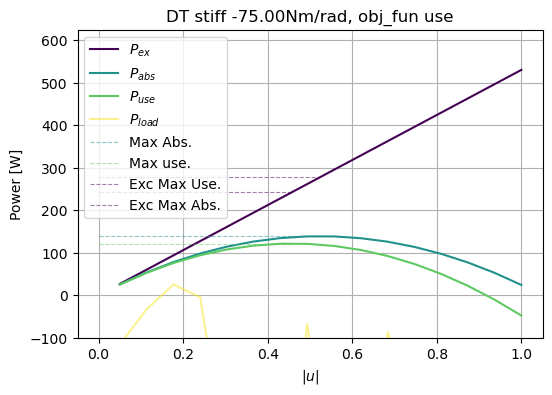

In [ ]:
Kms = -75
obj = 'use'
mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

V_target: 0.05, opt power: -248.49 W
V_target: 0.11, opt power: -545.57 W
V_target: 0.18, opt power: -782.70 W
V_target: 0.24, opt power: -959.89 W
V_target: 0.30, opt power: -1077.11 W
V_target: 0.37, opt power: -1134.39 W
V_target: 0.43, opt power: -1131.82 W
V_target: 0.49, opt power: -1069.38 W
V_target: 0.56, opt power: -946.99 W
V_target: 0.62, opt power: -764.65 W
V_target: 0.68, opt power: -522.36 W
V_target: 0.75, opt power: -220.12 W
V_target: 0.81, opt power: 142.08 W
V_target: 0.87, opt power: 564.22 W
V_target: 0.94, opt power: 1046.32 W
V_target: 1.00, opt power: 1588.37 W


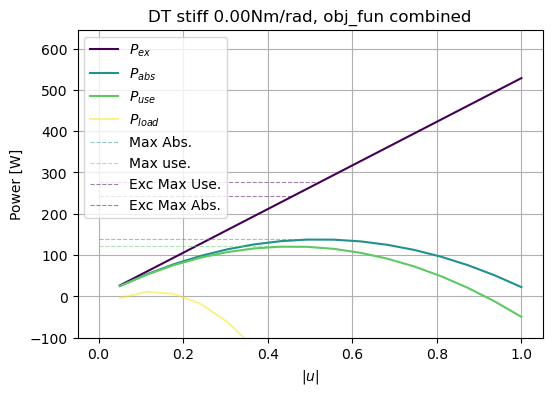

In [ ]:
Kms = 0
obj = 'combined'
mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

V_target: 0.05, opt power: -251.76 W
V_target: 0.11, opt power: -564.64 W
V_target: 0.18, opt power: -830.57 W
V_target: 0.24, opt power: -1049.56 W
V_target: 0.30, opt power: -1221.61 W
V_target: 0.37, opt power: -1346.73 W
V_target: 0.43, opt power: -1424.90 W
V_target: 0.49, opt power: -1456.13 W
V_target: 0.56, opt power: -1440.55 W
V_target: 0.62, opt power: -1378.05 W
V_target: 0.68, opt power: -1268.60 W
V_target: 0.75, opt power: -1112.22 W
V_target: 0.81, opt power: -908.90 W
V_target: 0.87, opt power: -658.64 W
V_target: 0.94, opt power: -361.44 W
V_target: 1.00, opt power: -17.30 W


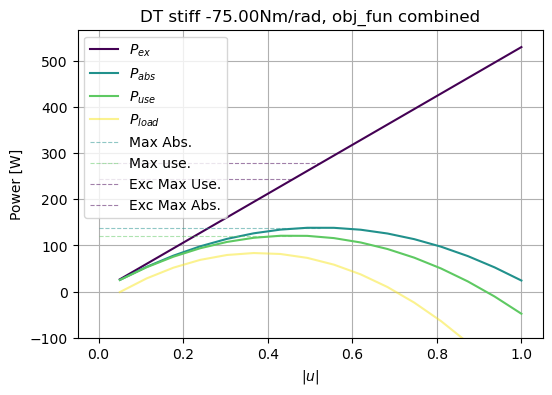

In [ ]:
Kms = -75
obj = 'combined'
mag_vel, mag_current, P_load, P_ex, P_abs, P_use, p_flows = power_flows_per_vel(K_DT = Kms, obj_fun = obj)
plot_power_curves(Kms, obj, mag_vel, P_load, P_ex, P_abs, P_use, p_flows)

In [ ]:
# Example for P_load
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mag_vel, mag_current, P_load, c='b', marker='o', label='P_load', alpha = 0.5)

ax.set_xlabel('Velocity')
ax.set_ylabel('Current')
ax.set_zlabel('P_load')
plt.title('P_load in flow space')
plt.show()

V_target: 0.40, opt power: -1393.72 W


(array([0.66101247]), array([0.63659766]))

[09:06:09] WARNING  Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.

           WARNING  Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.

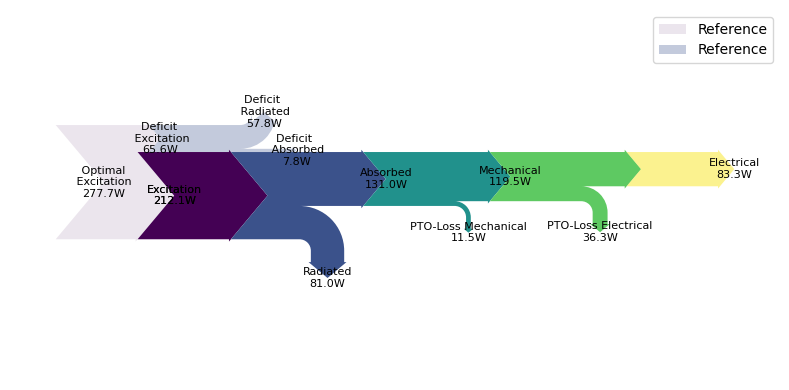

In [ ]:

Kms = -75
obj = 'combined'
wec, pto, results = wec_pto_and_res_enforced_vel(0.4, K_DT= Kms, obj_fun= obj)
p_flows = wot.utilities.calculate_power_flows(wec, pto, results, waves, Zi)
wot.utilities.plot_power_flow(p_flows)
# p_flows
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)

w_fd = wec_fdom[0]
p_fd = pto_fdom[0]

p_flows
Fexc = w_fd['force'].sel(type = ['Froude_Krylov', 'diffraction']).sum(dim = 'type')
np.angle(w_fd.vel[1]), np.angle(Fexc[1].values)


In [ ]:
p_flows

{'Optimal Excitation': 277.70271753612184,
 'Max Absorbed': 138.85135876806092,
 'Max Useful': 121.55820543447982,
 'Radiated': 81.01766460920268,
 'Excitation': 212.0632787638253,
 'Electrical': 83.26539369813003,
 'Mechanical': 119.51985251813197,
 'Absorbed': 131.04561415462263,
 'Deficit Excitation': 65.63943877229653,
 'Deficit Absorbed': 7.805744613438293,
 'Deficit Radiated': 57.833694158858236,
 'PTO Loss Mechanical': 11.525761636490657,
 'PTO Loss Electrical': 36.25445882000194}